# Batch Normalization

## Importing Necessary Libraries

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

## Loading the Dataset

In [2]:
X, y = make_moons(10000, noise=0.8, random_state=42)

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

## Model Building without Batch Normalization

In [82]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(30, activation='relu'),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [83]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 30)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571 (2.23 KB)

 Trainable params: 571 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [85]:
history = model.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6468 - loss: 0.6129 - val_accuracy: 0.7345 - val_loss: 0.5371
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7525 - loss: 0.5089 - val_accuracy: 0.7365 - val_loss: 0.5333
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7459 - loss: 0.5160 - val_accuracy: 0.7375 - val_loss: 0.5345
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7542 - loss: 0.5049 - val_accuracy: 0.7365 - val_loss: 0.5329
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7481 - loss: 0.5188 - val_accuracy: 0.7375 - val_loss: 0.5326
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7517 - loss: 0.5101 - val_accuracy: 0.7370 - val_loss: 0.5327
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7416 - loss: 0.5223 - val_accuracy: 0.7345 - val_loss: 0.5348
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7460 - loss: 0.5123 - val_accu

KeyboardInterrupt: 

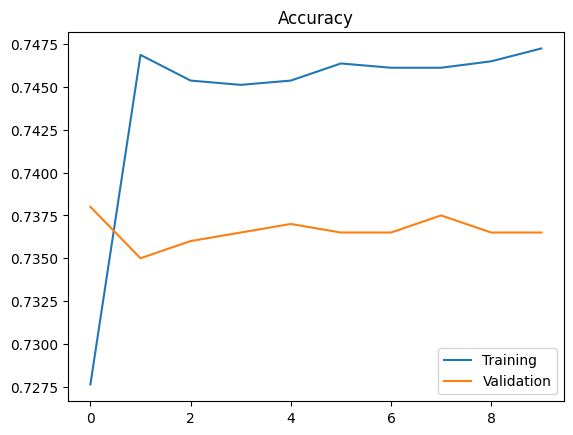

In [ ]:
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

## Model Building with Batch Normalization

In [ ]:
model_2 = keras.Sequential(
    [
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(30, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(1, activation='sigmoid')
    ]
)


In [ ]:
model_2.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 30)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 15)             │            60 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751 (2.93 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 90 (360.00 B)

In [ ]:
model_2.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [ ]:
history_2 = model_2.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7181 - loss: 0.5555 - val_accuracy: 0.7365 - val_loss: 0.5436
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7339 - loss: 0.5317 - val_accuracy: 0.7355 - val_loss: 0.5329
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7435 - loss: 0.5201 - val_accuracy: 0.7340 - val_loss: 0.5322
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7433 - loss: 0.5250 - val_accuracy: 0.7355 - val_loss: 0.5333
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7468 - loss: 0.5178 - val_accuracy: 0.7360 - val_loss: 0.5313
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7451 - loss: 0.5192 - val_accuracy: 0.7325 - val_loss: 0.5330
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7444 - loss: 0.5243 - val_accuracy: 0.7290 - val_loss: 0.5315
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7465 - loss: 0.5175 - val_accuracy: 0.

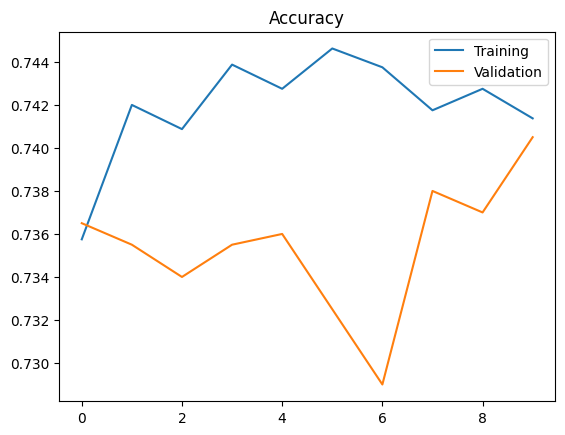

In [ ]:
plt.plot(history_2.history['accuracy'], label='Training')
plt.plot(history_2.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

## Batch Normalization vs No Batch Normalization

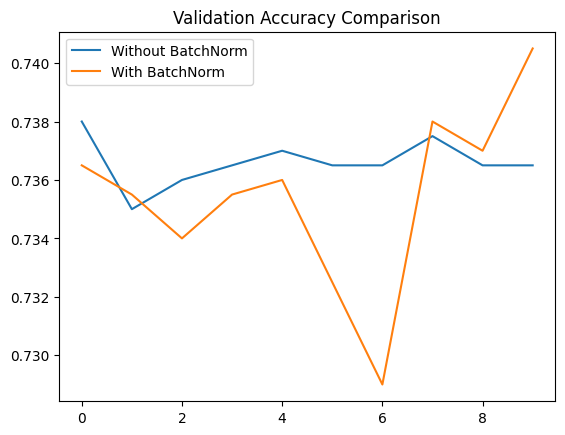

In [ ]:
plt.plot(history.history['val_accuracy'], label='Without BatchNorm')
plt.plot(history_2.history['val_accuracy'], label='With BatchNorm')
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()